# Python Analyzers – Set C
## Healthcare Hospital Operations Analysis

In [20]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [22]:

df = pd.read_csv("health_care .csv.csv")
df.shape


(68000, 10)

In [23]:
df.head()

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
2,800002,2023-12-30,NaN,Chennai,Neurology,Inpatient,8.0,403505.37,Private,Recovered
3,800003,2023-08-02,NaN,Chennai,Neurology,Outpatient,22.0,19975.17,Private,Recovered
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,NaN,434580.60,Government,NaN


In [24]:
df.tail()

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
67995,821041,2024-05-31,Central,Pune,Oncology,Inpatient,21.0,463084.12,Self-Pay,Recovered
67996,844371,2023-11-07,NaN,Delhi,NaN,NaN,14.0,347293.28,Self-Pay,Critical
67997,835040,2023-10-30,NaN,NaN,Cardiology,Inpatient,6.0,367992.20,Self-Pay,Referred
67998,855047,2024-03-02,East,Chennai,Neurology,Inpatient,27.0,20610.72,Self-Pay,Recovered
67999,815102,2022-10-11,Central,Mumbai,NaN,Outpatient,17.0,73405.17,Self-Pay,Recovered


## Data Cleaning & EDA

In [25]:

df.isnull().sum()


Patient_ID                 0
Admission_Date             0
Hospital_Region        17082
City                    7519
Department              6862
Patient_Type            6805
Length_of_Stay_Days     2271
Treatment_Cost             0
Insurance_Type          6692
Discharge_Status        6725
dtype: int64

In [30]:

df['Treatment_Cost'].fillna(df['Treatment_Cost'].median(), inplace=True)
df['Length_of_Stay_Days'].fillna(df['Length_of_Stay_Days'].median(), inplace=True)
df.dropna(subset=['Admission_Date','Department','Hospital_Region'], inplace=True)
df

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,15.0,434580.60,Government,NaN
6,800006,2022-02-27,Central,NaN,General,Inpatient,21.0,222727.57,NaN,Recovered
8,800008,2022-04-13,East,NaN,Cardiology,Outpatient,15.0,244403.63,Government,Recovered
...,...,...,...,...,...,...,...,...,...,...
64995,864995,2023-08-24,North,Delhi,General,Inpatient,26.0,469962.95,Private,Recovered
64996,864996,2023-10-11,East,Chennai,Orthopedics,NaN,10.0,207500.17,Government,Critical
64997,864997,2022-09-26,South,Chennai,Pediatrics,Outpatient,29.0,240159.01,Government,Critical
64998,864998,2022-10-09,Central,Kolkata,Orthopedics,Outpatient,3.0,257532.07,Private,Recovered


In [29]:

df.drop_duplicates(inplace=True)
df


,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,15.0,434580.60,Government,NaN
6,800006,2022-02-27,Central,NaN,General,Inpatient,21.0,222727.57,NaN,Recovered
8,800008,2022-04-13,East,NaN,Cardiology,Outpatient,15.0,244403.63,Government,Recovered
...,...,...,...,...,...,...,...,...,...,...
64995,864995,2023-08-24,North,Delhi,General,Inpatient,26.0,469962.95,Private,Recovered
64996,864996,2023-10-11,East,Chennai,Orthopedics,NaN,10.0,207500.17,Government,Critical
64997,864997,2022-09-26,South,Chennai,Pediatrics,Outpatient,29.0,240159.01,Government,Critical
64998,864998,2022-10-09,Central,Kolkata,Orthopedics,Outpatient,3.0,257532.07,Private,Recovered


In [28]:

df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df.describe()


,Patient_ID,Admission_Date,Length_of_Stay_Days,Treatment_Cost
count,43785.000000,43785,43785.000000,43785.000000
mean,832374.630992,2023-03-27 01:18:14.429599232,14.990156,249268.358777
min,800000.000000,2022-01-01 00:00:00,1.000000,532.270000
25%,816095.000000,2022-08-14 00:00:00,8.000000,123092.910000
50%,832336.000000,2023-03-28 00:00:00,15.000000,248258.960000
75%,848595.000000,2023-11-08 00:00:00,22.000000,374453.810000
max,864999.000000,2024-06-18 00:00:00,29.000000,499983.650000
std,18769.180831,NaN,8.229849,144704.906042


## Analysis

In [ ]:

df.groupby('Department')['Treatment_Cost'].mean()
df


,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,15.0,434580.60,Government,NaN
6,800006,2022-02-27,Central,NaN,General,Inpatient,21.0,222727.57,NaN,Recovered
8,800008,2022-04-13,East,NaN,Cardiology,Outpatient,15.0,244403.63,Government,Recovered
...,...,...,...,...,...,...,...,...,...,...
64995,864995,2023-08-24,North,Delhi,General,Inpatient,26.0,469962.95,Private,Recovered
64996,864996,2023-10-11,East,Chennai,Orthopedics,NaN,10.0,207500.17,Government,Critical
64997,864997,2022-09-26,South,Chennai,Pediatrics,Outpatient,29.0,240159.01,Government,Critical
64998,864998,2022-10-09,Central,Kolkata,Orthopedics,Outpatient,3.0,257532.07,Private,Recovered


In [32]:

df.groupby('Patient_Type')['Length_of_Stay_Days'].mean()
df

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,15.0,434580.60,Government,NaN
6,800006,2022-02-27,Central,NaN,General,Inpatient,21.0,222727.57,NaN,Recovered
8,800008,2022-04-13,East,NaN,Cardiology,Outpatient,15.0,244403.63,Government,Recovered
...,...,...,...,...,...,...,...,...,...,...
64995,864995,2023-08-24,North,Delhi,General,Inpatient,26.0,469962.95,Private,Recovered
64996,864996,2023-10-11,East,Chennai,Orthopedics,NaN,10.0,207500.17,Government,Critical
64997,864997,2022-09-26,South,Chennai,Pediatrics,Outpatient,29.0,240159.01,Government,Critical
64998,864998,2022-10-09,Central,Kolkata,Orthopedics,Outpatient,3.0,257532.07,Private,Recovered


## Visualizations

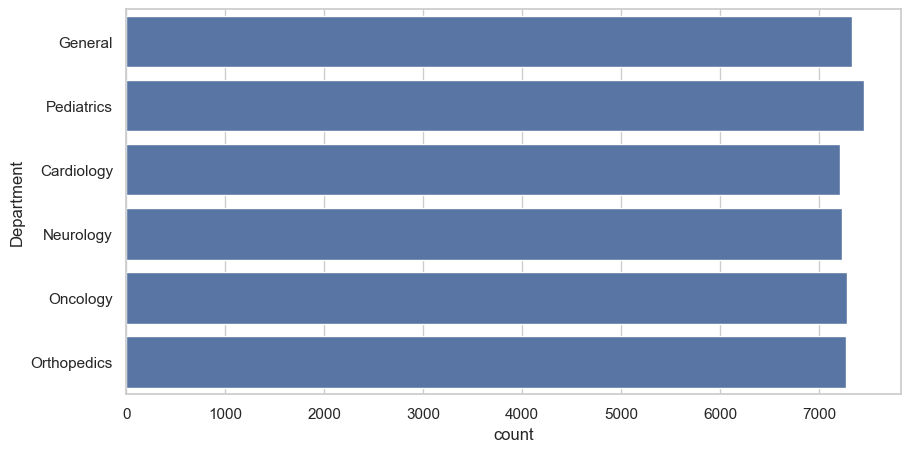

In [33]:

plt.figure(figsize=(10,5))
sns.countplot(y='Department', data=df)
plt.show()


C:\Users\ayush\AppData\Local\Temp\ipykernel_37496\2489435384.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Admission_Date').resample('M').size().plot(figsize=(10,5))


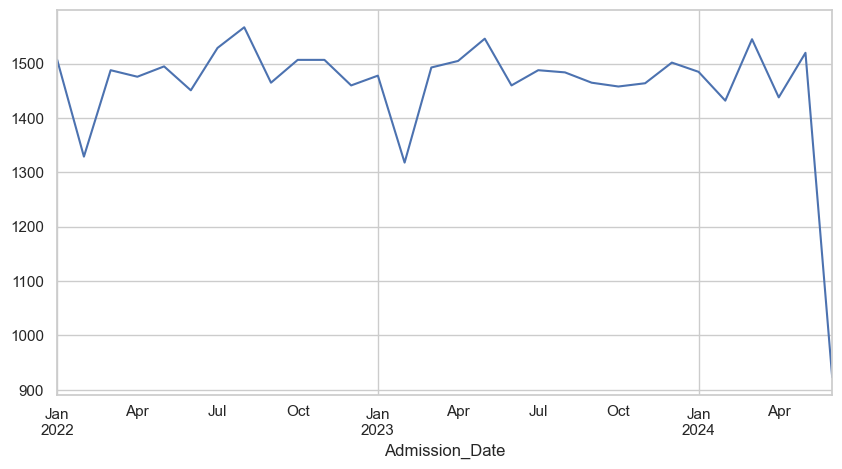

In [34]:

df.set_index('Admission_Date').resample('M').size().plot(figsize=(10,5))
plt.show()


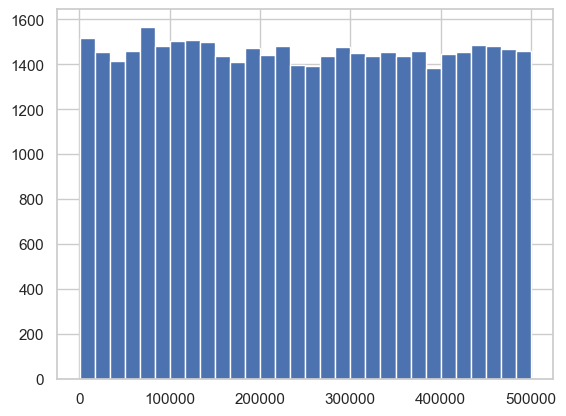

In [35]:

plt.hist(df['Treatment_Cost'], bins=30)
plt.show()


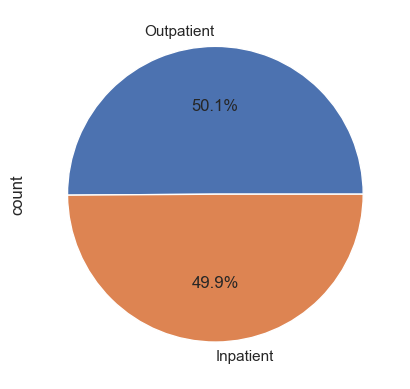

In [36]:

df['Patient_Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()


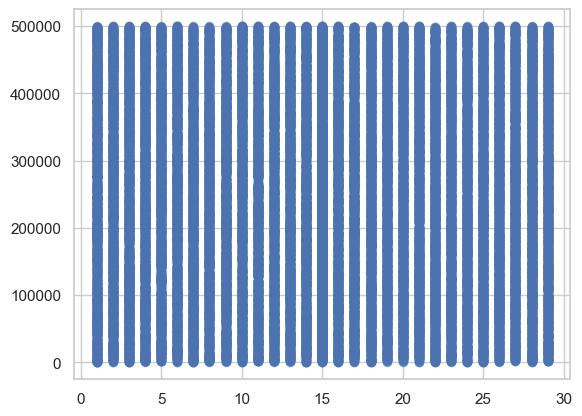

In [37]:

plt.scatter(df['Length_of_Stay_Days'], df['Treatment_Cost'], alpha=0.5)
plt.show()


SUMMARY OF THE FULL PROJECT

1. creat a note book  and do it in to perfact formate .

2 . Hear i will perform data clening task .

3 . Analysis the data .

4 . creat data in to chart form and visualysis the data .